# ВЫПУСКНАЯ КВАЛИФИКАЦИОННАЯ РАБОТА 

### Тема:
### *«Методы классификации текстовых документов на основе дообучения большой языковой модели»*

### EDA - Разведочный анализ данных

___

Произведем импорт необходимых библиотек.

In [108]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import matplotlib.colors as mcolors
import numpy as np
from adjustText import adjust_text
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.decomposition import PCA
import plotly.express as px
import json
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from gensim import corpora
from gensim.models import LdaMulticore
import pyLDAvis
import pyLDAvis.gensim_models as gensim_lda
from pathlib import Path

___
Вынесем в  отдельный блок функции для построения читаемых графиков

In [ ]:
def plot_length_distribution(data, column='char_count', bins=150):
    'Гистограмма и ящик с усами '
    values = data[column].dropna()

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        gridspec_kw={'height_ratios': [4, 1]}
    )

    # Гистограмма
    ax1.hist(values, bins=bins, color="#3151A3", edgecolor='white')
    ax1.set_ylabel('Количество')
    ax1.set_title(f'Распределение количества {column}')
    
    median_val = values.median()
    mean_val = values.mean()

    ax1.axvline(median_val, color='red', linestyle='--',
                label=f'Медиана: {median_val:.0f}')
    ax1.axvline(mean_val, color='orange', linestyle='--',
                label=f'Среднее: {mean_val:.0f}')
    ax1.legend()

    # Boxplot
    ax2.boxplot(
        values,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="#3258B8D8", alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='gray',
                        markersize=3, alpha=0.4)
    )
    ax2.set_xlabel(column)
    ax2.set_yticks([])

    plt.tight_layout()
    plt.show()

In [110]:


def plot_length_distribution(data, column='char_count', bins=150):
    'Гистограмма и ящик с усами '
    values = data[column].dropna()

    # >>> ДОБАВИЛ: глобальное увеличение шрифтов
    plt.rcParams.update({
        'font.size': 16,          # базовый размер
        'axes.titlesize': 20,     # заголовки
        'axes.labelsize': 18,     # подписи осей
        'xtick.labelsize': 14,    # подписи делений X
        'ytick.labelsize': 14,    # подписи делений Y
        'legend.fontsize': 14     # легенда
    })

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        gridspec_kw={'height_ratios': [4, 1]}
    )

    # Гистограмма
    ax1.hist(values, bins=bins, color="#3151A3", edgecolor='white')
    
    ax1.set_ylabel('Количество')  # шрифт уже увеличен через rcParams
    
    # >>> ДОБАВИЛ: fontsize для заголовка (можно переопределить отдельно)
    ax1.set_title(
        f'Распределение количества слов в письмах до очистки',
        fontsize=20
    )
    
    median_val = values.median()
    mean_val = values.mean()

    ax1.axvline(median_val, color='red', linestyle='--',
                label=f'Медиана: {median_val:.0f}')
    ax1.axvline(mean_val, color='orange', linestyle='--',
                label=f'Среднее: {mean_val:.0f}')
    
    # >>> ДОБАВИЛ: увеличенный шрифт легенды (можно управлять отдельно)
    ax1.legend(fontsize=14)

    # Boxplot
    ax2.boxplot(
        values,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="#3258B8BB", alpha=0.6),
        
        # >>> ДОБАВИЛ: увеличил толщину линии медианы для видимости
        medianprops=dict(color='red', linewidth=3),
        
        flierprops=dict(marker='o', markerfacecolor='gray',
                        markersize=5, alpha=0.4)  # >>> увеличил размер точек
    )
    
    # >>> ДОБАВИЛ: fontsize для подписи оси X
    ax2.set_xlabel(column, fontsize=18)
    
    ax2.set_yticks([])

    plt.tight_layout()
    plt.show()

In [111]:
def plot_metric_by_label(df: pd.DataFrame, metric: str = None, ascending: bool = True):
    """
    Строит красивый горизонтальный барчарт по блокам (label).
    """

    # Если метрика не указана — считаем количество писем в каждом блоке
    if metric is None:
        data = df['label'].value_counts().sort_values(
            ascending=ascending).to_frame()
        metric = 'count'
    # Иначе — считаем среднее значение метрики по каждому блоку
    else:
        data = df.groupby('label')[[metric]].mean(
        ).sort_values(metric, ascending=ascending)

    fig, ax = plt.subplots(figsize=(12, 14))

    # Градиент цвета 
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(data)))
    bars = ax.barh(data.index, data[metric], color=colors,
                   edgecolor='white', linewidth=0.5, height=0.7)

    # числовое значение справа от каждого бара
    for bar, val in zip(bars, data[metric]):
        ax.text(
            val + data[metric].max() * 0.01,        
            bar.get_y() + bar.get_height() / 2,     # по центру бара по высоте
            f'{val:.0f}' if metric == 'count' else f'{val:.3f}',  # формат числа
            va='center', ha='left', fontsize=8, color='#333333'
        )

    # Вертикальная линия медианы 
    median_val = data[metric].median()
    ax.axvline(median_val, color='steelblue',
               linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(
        median_val + data[metric].max() * 0.005, -0.8,
        f'медиана\n{median_val:.0f}' if metric == 'count' else f'медиана\n{median_val:.3f}',
        fontsize=8, color='steelblue', va='top'
    )

    # Заголовок и подпись оси зависят от того что строим
    title = 'Распределение количества писем по блокам' if metric == 'count' else f'{metric} по блокам'
    xlabel = 'Количество писем' if metric == 'count' else f'{metric} (среднее)'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=11)

    # место справа чтобы подписи не обрезались
    ax.set_xlim(0, data[metric].max() * 1.15)

    # убираем лишние рамки 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.tick_params(axis='y', labelsize=9)

    # Сетка на задний план
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'{metric}_by_label.png', dpi=150, bbox_inches='tight')
    plt.show()

In [112]:
def plot_scatter_two_metrics(df: pd.DataFrame,
                             metric_x: str,
                             metric_y: str):
    """
    Строит scatter plot соотношения двух метрик по блокам (label).
    """

    agg = df.groupby('label')[[metric_x, metric_y]].mean().reset_index()

    score = (agg[metric_x] - agg[metric_x].min()) / \
        (agg[metric_x].max() - agg[metric_x].min())

    fig, ax = plt.subplots(figsize=(16, 10))

    ax.scatter(agg[metric_x], agg[metric_y],
               c=score, cmap='RdYlGn',
               s=120, edgecolors='white', linewidth=0.8, zorder=3)

    # Собираем подписи отдельно — adjust_text сам их разведёт
    texts = []
    for _, row in agg.iterrows():
        texts.append(ax.text(
            row[metric_x], row[metric_y],
            row['label'],
            fontsize=7.5, color='#333333'
        ))

    # Разводим подписи — arrowprops рисует стрелку от подписи к точке
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.6),
        expand=(1.5, 1.8),       # насколько сильно разводить
        force_text=(0.5, 0.8),   # сила отталкивания между подписями
    )

    # Линии медиан
    x_med = agg[metric_x].median()
    y_med = agg[metric_y].median()
    ax.axvline(x_med, color='steelblue', linestyle='--',
               linewidth=1, alpha=0.6, label=f'медиана {metric_x}')
    ax.axhline(y_med, color='tomato',    linestyle='--',
               linewidth=1, alpha=0.6, label=f'медиана {metric_y}')

    # Подписи квадрантов
    x_min, x_max = agg[metric_x].min(), agg[metric_x].max()
    y_min, y_max = agg[metric_y].min(), agg[metric_y].max()
    quad_style = dict(fontsize=8, alpha=0.4, fontstyle='italic')
    ax.text(x_med + (x_max - x_med) * 0.6, y_max,
            'длинные и разнообразные',  ha='center', color='green',  **quad_style)
    ax.text(x_min + (x_med - x_min) * 0.3, y_max,
            'короткие и разнообразные', ha='center', color='olive',  **quad_style)
    ax.text(x_med + (x_max - x_med) * 0.6, y_min + 0.005,
            'длинные и шаблонные',      ha='center', color='tomato', **quad_style)
    ax.text(x_min + (x_med - x_min) * 0.3, y_min + 0.005,
            'короткие и шаблонные',     ha='center', color='gray',   **quad_style)

    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f'{metric_x} (нормализовано)', fontsize=9)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['мало', 'средне', 'много'])

    ax.set_xlabel(metric_x, fontsize=11)
    ax.set_ylabel(metric_y, fontsize=11)
    ax.set_title(f'{metric_x} vs {metric_y} по блокам',
                 fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'scatter_{metric_x}_{metric_y}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

___
Блок функций которые я использовал для очистки текста внутри писем.

In [113]:
# удаляем подряд идущие одинаковые слова
def remove_repeated_words(text: str):
    # пример: "работа работа работа" → "работа"
    return re.sub(r'\b(\w+)(\s+\1\b)+', r'\1', text, flags=re.IGNORECASE)

In [114]:
# удаляем длинные повторяющиеся куски (даже если это часть одного огромного предложения)
def remove_repeated_sequences(text: str, min_words=5, max_words=30):
    # это нужно когда повторяется фраза по 50-100 раз подряд
    words = text.split()
    i = 0
    result = []

    while i < len(words):
        found_repeat = False

        # проверяем куски разной длины
        for size in range(max_words, min_words - 1, -1):

            # если не хватает слов — просто пропускаем
            if i + size * 2 > len(words):
                continue

            phrase1 = words[i:i+size]
            phrase2 = words[i+size:i+size*2]

            # если нашли повтор
            if phrase1 == phrase2:
                result.extend(phrase1)

                # пропускаем ВСЕ одинаковые повторы подряд
                j = i + size
                while j + size <= len(words) and words[j:j+size] == phrase1:
                    j += size

                i = j
                found_repeat = True
                break

        if not found_repeat:
            result.append(words[i])
            i += 1

    return " ".join(result)

In [115]:
# убираем повторяющиеся строки (часто бывает в логах или выгрузках)
def remove_duplicate_lines(text: str):
    seen = set()
    cleaned_lines = []

    for line in text.split("\n"):
        normalized = line.strip().lower()
        if normalized and normalized not in seen:
            cleaned_lines.append(line.strip())
            seen.add(normalized)

    return "\n".join(cleaned_lines)

In [116]:
#  удаляем одинаковые предложения
def remove_duplicate_sentences(text: str):
    # делим по . ! ?
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    seen = set()
    result = []

    for s in sentences:
        s_clean = s.strip()
        key = s_clean.lower()
        if key and key not in seen:
            seen.add(key)
            result.append(s_clean)

    return " ".join(result)

In [117]:
#  чистим повторы через запятую
def remove_repeated_comma_phrases(text: str):
    pattern = r'(.{20,200}?)(?:,\s*\1){2,}'
    return re.sub(pattern, r'\1', text, flags=re.IGNORECASE)

In [118]:
# нормализация пробелов
def normalize_text(text: str):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n\s*\n+', '\n\n', text)
    return text.strip()


In [119]:
def remove_cycling_numbered_lines(text: str):
    lines = text.split('\n')
    
    # убираем "1.", "2." и т.д. чтобы сравнивать только содержимое
    contents = [re.sub(r'^\d+\.\s*', '', line.strip()) for line in lines]
    
    # dict.fromkeys убирает дубли но сохраняет порядок
    unique = list(dict.fromkeys(contents))
    
    # если уникальных строк сильно меньше чем всего — был цикл
    if len(unique) < len(contents) / 2:
        return '\n'.join(unique)
    
    return text

In [120]:

def remove_incremental_list(text: str) -> str:
    ' ищет паттерн: слово-число, слово-число, слово-число (5+ раз подряд)'
    pattern = r'(\[?[\w]+\]?-\d+)(?:[,\s]+\[?[\w]+\]?-\d+){4,}'
    
    def shrink(match):
        tokens = re.findall(r'\[?[\w]+\]?-\d+', match.group(0))
        # улаляем все повторы кроме 1 и последнего
        return f'{tokens[0]} ... {tokens[-1]}'
    
    return re.sub(pattern, shrink, text)

In [121]:
def trim_attached_documents(text: str, max_len: int = 4000) -> str:

    'Обрезает большие письма, содержащие таблицы, акты приложения'
    if len(text) <= max_len:
        return text
    
    triggers = [
        r'[Тт]абл[а-я]*\.?',
        r'Публичная оферта',
        r'заключили настоящий Договор о нижеследующем',
        r'1\.\s*Предмет договора',
        r'Термины и определения',
        r'Акт сверки взаимных расчетов',
        r'Акт\s+№?\s*\d+\s+о\s+нарушении',   # "Акт No123 о нарушении..."
        r'Приложение\s+\d+\s+к\s+приказу',    # "Приложение 1 к приказу..."
        r'ПОЛОЖЕНИЕ\s+О\s+',                   # "ПОЛОЖЕНИЕ О КОМИССИИ..."
        r'1\.\s*Общие положения',              # начало любого регламента
    ]
    
    earliest = len(text)
    for trigger in triggers:
        match = re.search(trigger, text)
        if match:
            earliest = min(earliest, match.start())
    
    if earliest < len(text):
        return text[:earliest].strip()
    
    return text

In [122]:
# Проходка по всем функциям
def clean_text(text: str):
    if not isinstance(text, str):
        return text
    
    # сначала убираем очевидный спам
    text = remove_repeated_words(text)
    # потом длинные повторяющиеся куски
    text = remove_repeated_sequences(text)
    # чистим повторяющиеся строки
    text = remove_duplicate_lines(text)
    # убираем дубли предложений
    text = remove_duplicate_sentences(text)
    # убираем повтор через запятую
    text = remove_repeated_comma_phrases(text)
    # удаляем циклы с разными номерами
    text = remove_cycling_numbered_lines(text)
    # 
    text = remove_incremental_list(text)
    # обрезает большие письма с таблицами, актами и тд
    text = trim_attached_documents(text)
    
    # финальная зачистка пробелов
    text = normalize_text(text)

    return text

___
### Знакомство с данными
Импортируем данные и произведем первичный анализ.

In [123]:
data = pd.read_json("/Users/kvt/Documents/VKR/code/Data/data.json")
# data = pd.read_json("../Data/data.json")
data.head()

,idx,text,label
0,10026,[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATI...,Блок директора по проектированию
1,1005,[ORGANIZATION] инжиниринг общество с ограничен...,Блок деректора по газу
2,1010,[ORGANIZATION] ИНВЕСТ Общество с ограниченной ...,Блок заместителя генерального директора по без...
3,10108,"[ORGANIZATION] ОГРН: [ID], ИНН/КПП: [ID] РФ, [...",Блок технического директора
4,1013,[ORGANIZATION] филиал [OBJECT] имени [PERSON] ...,Блок технического директора


___
Наши данные состоят из 3 столбцов:

- индекс письма,

- тект письма,

- целевая переменная.

Данные в тексте письма обезличены.
___

Оценим общую информацию

In [124]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1774 entries, 0 to 1773
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   idx     1774 non-null   object
 1   text    1774 non-null   object
 2   label   1774 non-null   object
dtypes: object(3)
memory usage: 41.7+ KB


In [125]:
data.describe()

,idx,text,label
count,1774,1774,1774
unique,1774,1769,36
top,17052P,[ORGANIZATION] Юридический адрес: [LOCATION] П...,Блок технического директора
freq,1,2,249


В данных у нас 1774 письма, и нет пропусков.

Всего существует 36 блоков.
___
Рассмотрим распределение по блокам

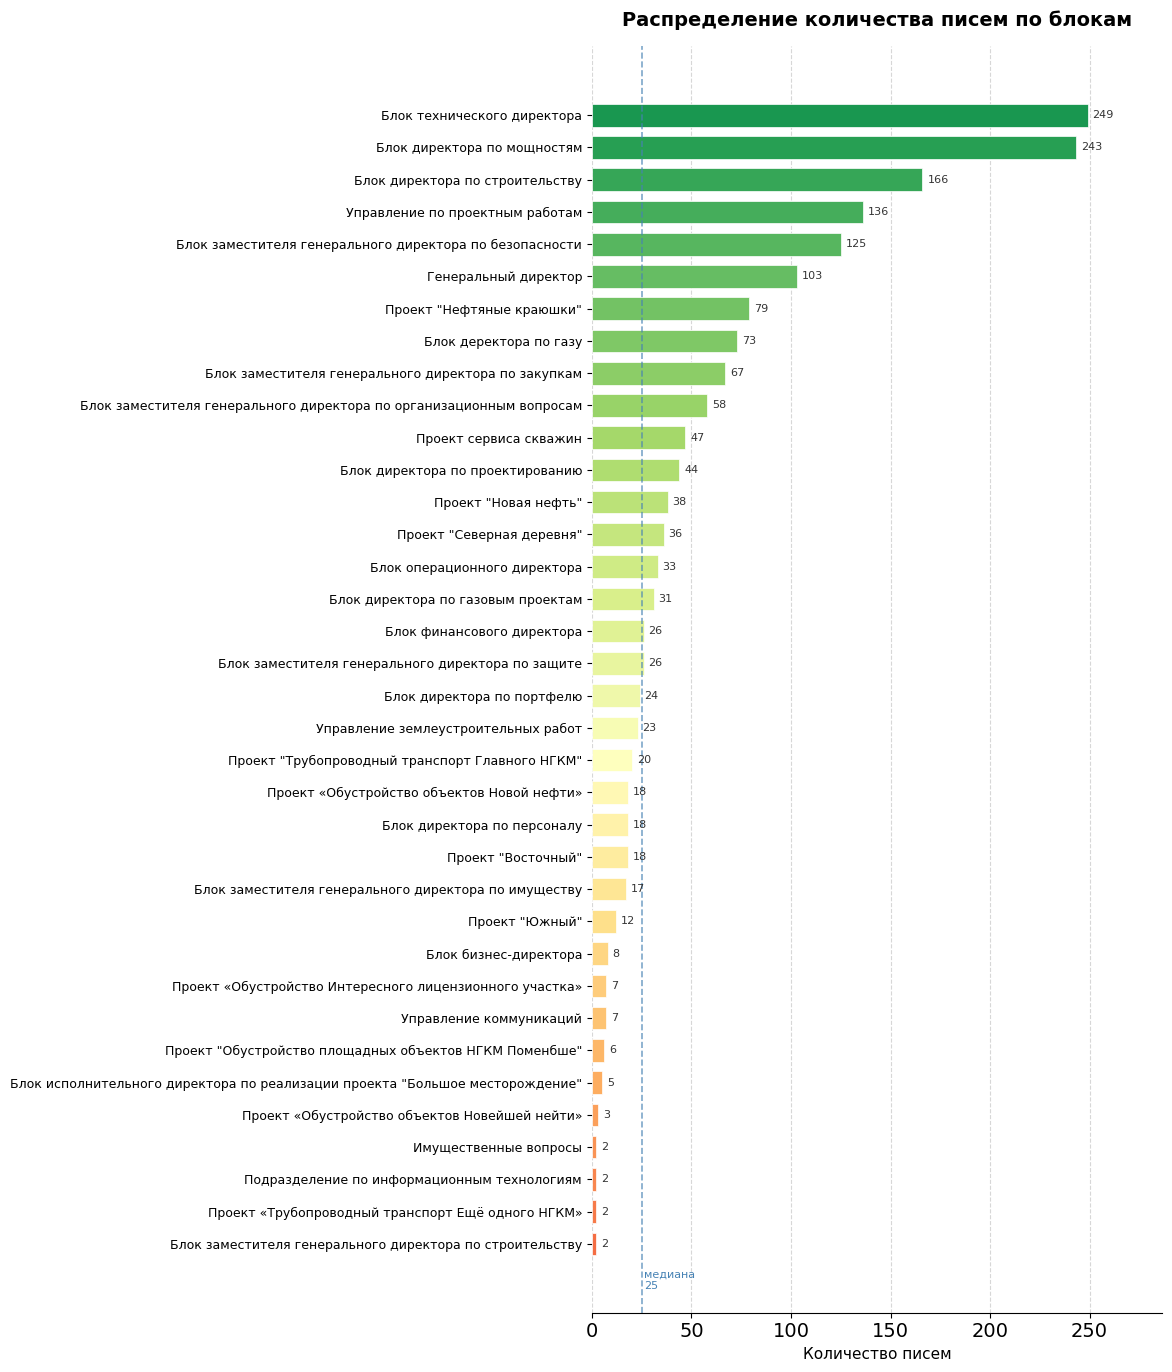

In [126]:
# распределение по количеству писем
plot_metric_by_label(data)

In [127]:
counts = data["label"].value_counts()
print("Блоков с < 10 примеров:", (counts < 10).sum())
print("Блоков с < 20 примеров:", (counts < 20).sum())

Блоков с < 10 примеров: 10
Блоков с < 20 примеров: 15


Малое количество примеров в блоке может вызвать проблемы в дальнейшем обучении. 

Необходимо будет найти подход для синтеза данных в этих блоках.
___

Попробуем поискать дубликаты в данных:

In [128]:
# удалим 'idx' так как он не несет информации
data = data.drop(columns='idx')
data_clean = data.drop_duplicates()
print(f"Было строк: {len(data)}")
print(f"Стало строк: {len(data_clean)}")
print(f"Удалено дубликатов: {len(data) - len(data_clean)}")
data = data_clean

Было строк: 1774
Стало строк: 1770
Удалено дубликатов: 4


In [129]:
# Дубликаты только текста
duplicates = data[data.duplicated(['text'], keep=False)]
print(f"Количество строк-дубликатов: {len(duplicates)}")
print("\nСтроки-дубликаты:")
duplicates

Количество строк-дубликатов: 2

Строки-дубликаты:


,text,label
103,[ORGANIZATION] ПРИКАЗ [DATE_TIME] No [DOCUMENT...,Имущественные вопросы
176,[ORGANIZATION] ПРИКАЗ [DATE_TIME] No [DOCUMENT...,Блок финансового директора


In [130]:
# Удаляем дубликат текста из "Блок финансового директора" (строка 176),
# оставляем в "Имущественные вопросы" (строка 103) — там меньше примеров
text_dupl = data[data.duplicated(['text'], keep=False)]
drop_idx = text_dupl[text_dupl['label'] == 'Блок финансового директора'].index
data = data.drop(index=drop_idx)
print(f"Удалено межклассовых дубликатов: {len(drop_idx)}")
print(f"Осталось строк: {len(data)}")

Удалено межклассовых дубликатов: 1
Осталось строк: 1769


___
### Поиск закономерностей и аномалий в простых текстовых параметрах
Теперь изучим параметры писем и сравним их по блокам.

Для этого оценим такие параметры как: 
- количество символов,
- общее количество слов в письме,
- количество предложений,
- количество уникальных слов в письме.


In [131]:
def basic_text_metrics(text: str) -> dict:
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

    return {
        'char_count':     len(text),
        'word_count':     len(words),
        'sentence_count': len(sentences),
        'unique_word_count': len(set(words)),
    }

In [132]:
metrics_data = data['text'].apply(lambda t: pd.Series(basic_text_metrics(t)))

data  = pd.concat([data, metrics_data], axis=1)

Выведем простые параметры и поищем закономерности.

In [133]:
data[['char_count', 'word_count', 'sentence_count',
     'unique_word_count', 'text']].sort_values('unique_word_count').head(20)

,char_count,word_count,sentence_count,unique_word_count,text
878,46565,3105,1,5,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...
836,49,6,1,5,МНН / КПП [ID] / [ID] Организация: [ORGANIZATION]
33,246,18,1,6,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...
252,46982,5217,1,6,[ORGANIZATION] [ORGANIZATION] [PERSON] [PERSON...
1637,261,19,1,6,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...
1191,118,10,1,6,[ORGANIZATION] [ORGANIZATION] [LOCATION] [CONT...
733,179,13,1,6,[ORGANIZATION] [ORGANIZATION] [ORGANIZATION] [...
792,53932,4230,1,7,"[ORGANIZATION]: [DOCUMENT_NUMBER], [ID] [DATE_..."
743,44872,4983,1,7,[ORGANIZATION] [LOCATION] [CONTACT] [ORGANIZAT...
1019,46798,5197,1,7,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...


Вижу, что в данных присутствуют такие письма, где несколько тысяч слов, при этом уникальных слов 5-10, это явно похоже на аномалию.
Выделим письма где уникальных слов меньше 30, а слов больше 200.

In [134]:
mask = (data['unique_word_count'] < 50) & (data['word_count'] > 200)
print(f"Обнаружено {len(data[mask])} аномальных писем.")
data = data.drop(data[mask].index)
print("Письма удалены")

Обнаружено 19 аномальных писем.
Письма удалены


In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1750 entries, 0 to 1773
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               1750 non-null   object
 1   label              1750 non-null   object
 2   char_count         1750 non-null   int64 
 3   word_count         1750 non-null   int64 
 4   sentence_count     1750 non-null   int64 
 5   unique_word_count  1750 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 95.7+ KB


___
Посмортрим распределение по количеству символов.

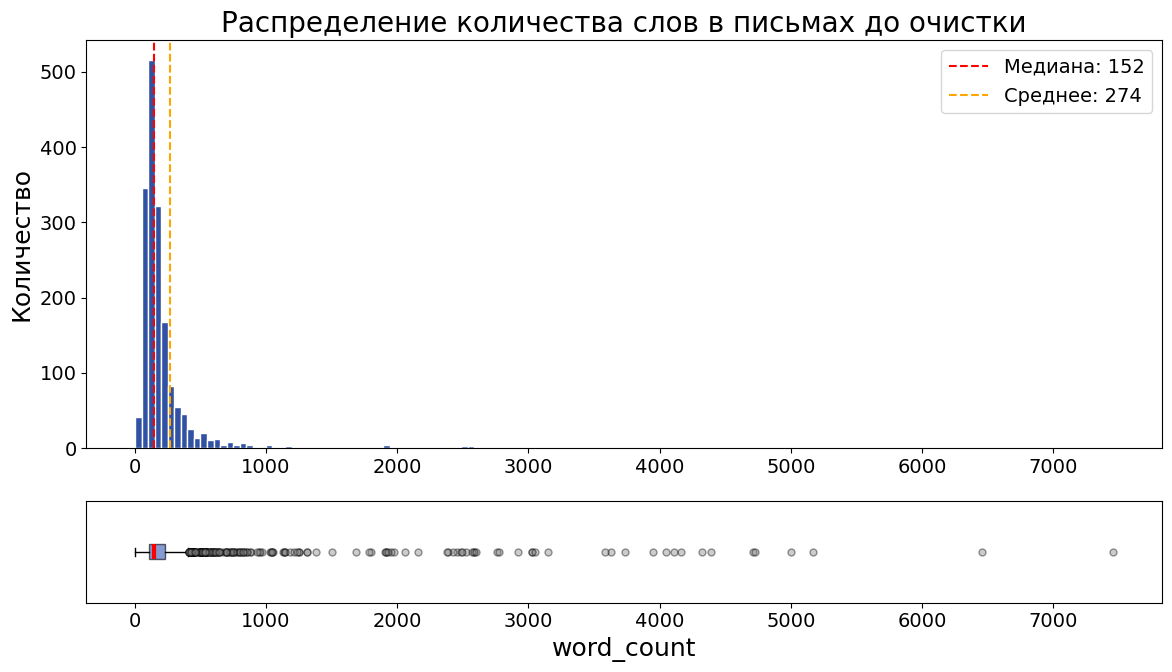

In [136]:
plot_length_distribution(data, 'word_count')

Посмотрим самое длинное письмо, является ли оно аномальным по содержанию. 

In [99]:
data['word_count'].describe()

count    1750.000000
mean      273.516571
std       531.872022
min         6.000000
25%       109.250000
50%       151.500000
75%       230.000000
max      7456.000000
Name: word_count, dtype: float64

In [100]:
#намеренно урезал до 1000 символов
print(data[data['word_count'] == 7456]['text'].iloc[0][:1000])

Благоустройство [LOCATION] [ORGANIZATION] [PERSON] Тема: Запрос на подписание баланса на [OBJECT] Уважаемая [PERSON]! В связи с производственной необходимостью, во избежание срыва оказания услуг по обеспечению [OBJECT] и необходимости работ по созданию сметы величины баланса, ООО Благоустройство [LOCATION] просит Вас согласовать подписание баланса [DATE_TIME]: No ПП Должность [PERSON] Текущий срок окончания Конечный срок окончания Дата  1 Специалист по ремонту и обслуживанию систем теплоснабжения и кондиционирования [PERSON] [NUMBER] [NUMBER] [DATE_TIME] 2 Электромонтажник (6-7 рабочих дней) [PERSON] [NUMBER] [NUMBER] [DATE_TIME] Сообщаем, что сотрудники не могут приступить к работе до получения баланса, а также не могут приступить к работе до получения баланса, а также не могут приступить к работе до получения баланса, а также не могут приступить к работе до получения баланса, а также не могут приступить к работе до получения баланса, а также не могут приступить к работе до получения 

Данное письмо содержит много копий одного предложения и явно  является аномалией. 

Так же письма  могут содержать дубликаты повторяющихся подряд, фраз слов, строк, а так же другие паттерны. 
___
Пройдемся по письмам и удалим  все лишнее, для этого используются функции из блока выше.

In [101]:
# удаляем дубликаты(строк, фпраз, предложений) в тексте
data['text'] = data['text'].apply(clean_text)

#Удаляем базовые параметры и пересчитываем их заново
data = data.drop(columns=['char_count', 'word_count', 'sentence_count',
     'unique_word_count'])

metrics_data = data['text'].apply(lambda x: pd.Series(basic_text_metrics(x)))

data  = pd.concat([data, metrics_data], axis=1)

После удаления построим наш график заново

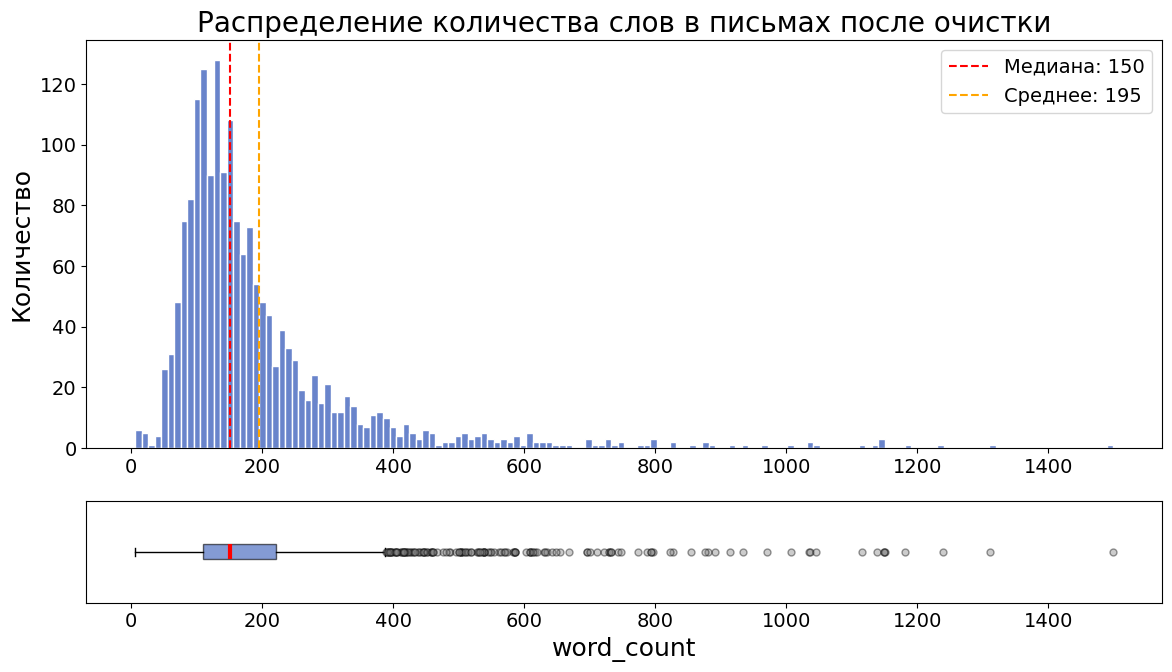

In [106]:
plot_length_distribution(data, 'word_count')

Количество выбросов явно сократилось.

In [135]:
data['char_count'].describe()

count     1750.000000
mean      1619.432000
std       1267.995999
min         49.000000
25%        909.000000
50%       1244.500000
75%       1838.000000
max      12123.000000
Name: char_count, dtype: float64

Посмотрим на предложение  содерджащее более всего символов.

In [136]:
print(data[data['char_count'] == 12123]['text'].iloc[0])

[ORGANIZATION] ООО [OBJECT] МетИз ИНН [ID] / КПП [ID] / ОГРН [DOCUMENT_NUMBER] [LOCATION] ИСХ No [DOCUMENT_NUMBER] от [DATE_TIME] [PERSON] по закупкам [ORGANIZATION] [PERSON] Генеральному директору [ORGANIZATION] [PERSON] Заместителю генерального директора по закупкам [ORGANIZATION] [PERSON] Уважаемый [PERSON]! Уважаемый [PERSON]! В ответ на Ваше письмо рег. No [CONTACT] от [DATE_TIME] поступившее на эл. Адрес [CONTACT] [DATE_TIME] (Далее- письмо), сообщаем следующее: 1. Содержание письма: В соответствии с условиями документации о конкурентном отборе (п.3.5. приложения No4 к закупочной документации Информационная карта), договор по итогам и на условиях отбора заключается не позднее 20 (двадцати) календарных дней с момента уведомления о результатах отбора в соответствии с итогами закупочной процедуры, проведенной на равных конкурентных условиях для всех ее участников. В случае наличия между Сторонами заключенного ранее типового Договора поставки (рамочного согласно п.1 ст. 429.1 ГК РФ),

Данное письмо хоть и длинное, но уже не выглядит как аномалия, с повторяющимися фразами или предложениями.

___ 
Построим аналогичную диаграмму по количеству слов.

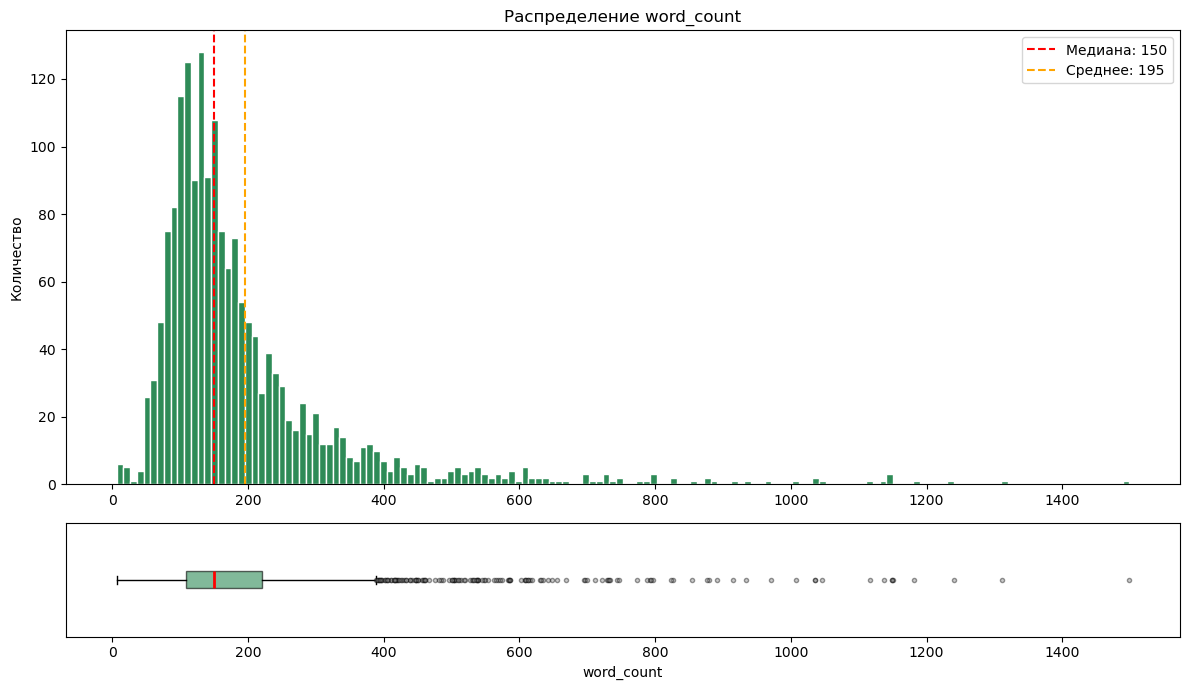

In [137]:
plot_length_distribution(data, 'word_count')

Для количества уникальных слов.

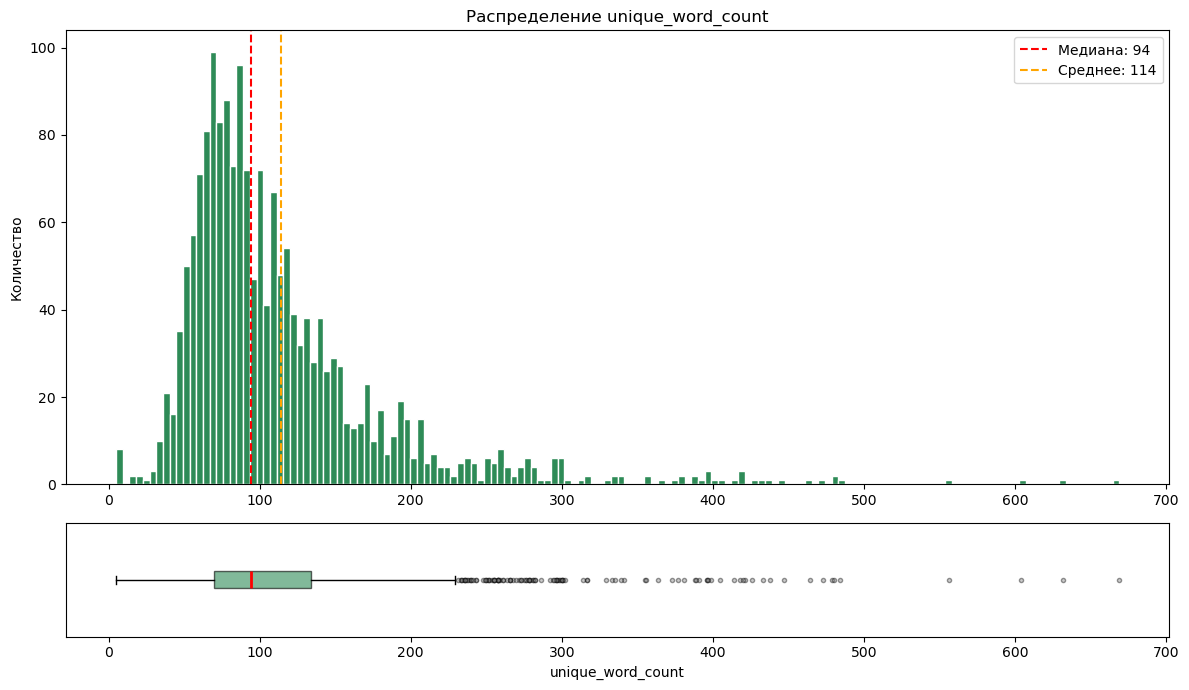

In [138]:
plot_length_distribution(data, 'unique_word_count')

Распределения в целом похожи на распределение количества символов.

Рассмотрим средние показатели по блокам.

In [139]:
data.groupby('label')[['char_count', 'word_count', 'sentence_count', 'unique_word_count'
                       ]].mean().sort_values('unique_word_count', ascending=False)

,char_count,word_count,sentence_count,unique_word_count
label,,,,
Проект «Трубопроводный транспорт Ещё одного НГКМ»,1947.000000,238.500000,12.000000,158.000000
"Блок исполнительного директора по реализации проекта ""Большое месторождение""",2042.500000,242.000000,14.000000,151.000000
Блок заместителя генерального директора по безопасности,2399.609756,282.796748,15.593496,148.081301
Подразделение по информационным технологиям,1633.500000,192.000000,11.000000,140.000000
"Проект ""Северная деревня""",1907.833333,228.833333,15.527778,136.527778
Имущественные вопросы,2271.000000,288.500000,31.000000,135.500000
Блок заместителя генерального директора по имуществу,1973.437500,241.875000,15.750000,132.937500
Блок технического директора,1802.276423,221.955285,15.471545,128.963415
Генеральный директор,1840.019608,218.568627,13.382353,128.147059


Общий вывод — данные выглядят чистыми и однородными, серьёзных аномалий нет.

Подразделения в нижней части таблицы пишут короче и проще, в верхней — длиннее и богаче по словарю. 

___
### Поиск закономерностей и аномалий в других текстовых параметрах
Перейдем к оценке более сложных параметров:
- TTR — Type-Token Ratio - отношение уникальных слов к общему числу слов. Чем выше данный параметр, тем лексически разнообразней составлено письмо что может указывать на большую специфику, например технические или юридические термины.
- RTTR — Root Type-Token Ratio -  так же харрактеризует отношение уникальных слов к общему числу слов, но за счет деления на корень квадратный из общего количества слов компенсирует зависимость от длины всего текста, что позволяет сравнивать между собой короткие и длинные письма.
- Средняя длинна слова - так же может позволить отделить письма с проффессиональной терминологией от писем общего харрактера.
- Среднее количество слов в предложении - сложносочиненные предложения могут отражать бюрократические или юридические письма, в то же время более простые могут намекать на операционную деятельность.
- Доля длинных слов более 8 символов - чем выше данный показатель, тем как правило больше используется терминологии.
- Доля уникальных слов hapax

In [140]:
def advanced_text_metrics(text: str):
    'Функция для расчета параметров'
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    word_count = len(words)

    if word_count == 0:
        return {
            'ttr': 0,
            'rttr': 0,
            'avg_word_length': 0,
            'avg_sentence_length': 0,
            'long_word_ratio': 0,
            'hapax_ratio': 0,
        }

    unique_words = set(words)
    word_freq = Counter(words)

    return {
        # Лексическое разнообразие
        'ttr':  len(unique_words) / word_count,
        'rttr': len(unique_words) / (word_count ** 0.5),

        # Средние длины
        'avg_word_length': sum(len(w) for w in words) / word_count,
        'avg_sentence_length': word_count / len(sentences) if sentences else 0,

        # Сложность
        'long_word_ratio': sum(1 for w in words if len(w) > 8) / word_count,
        'hapax_ratio': sum(1 for w, c in word_freq.items() if c == 1) / word_count,
    }

In [141]:
advanced_df = data['text'].apply(advanced_text_metrics).apply(pd.Series)
data  = pd.concat([data, advanced_df], axis=1)

___
Рассмотрим 'ttr'  по блокам.

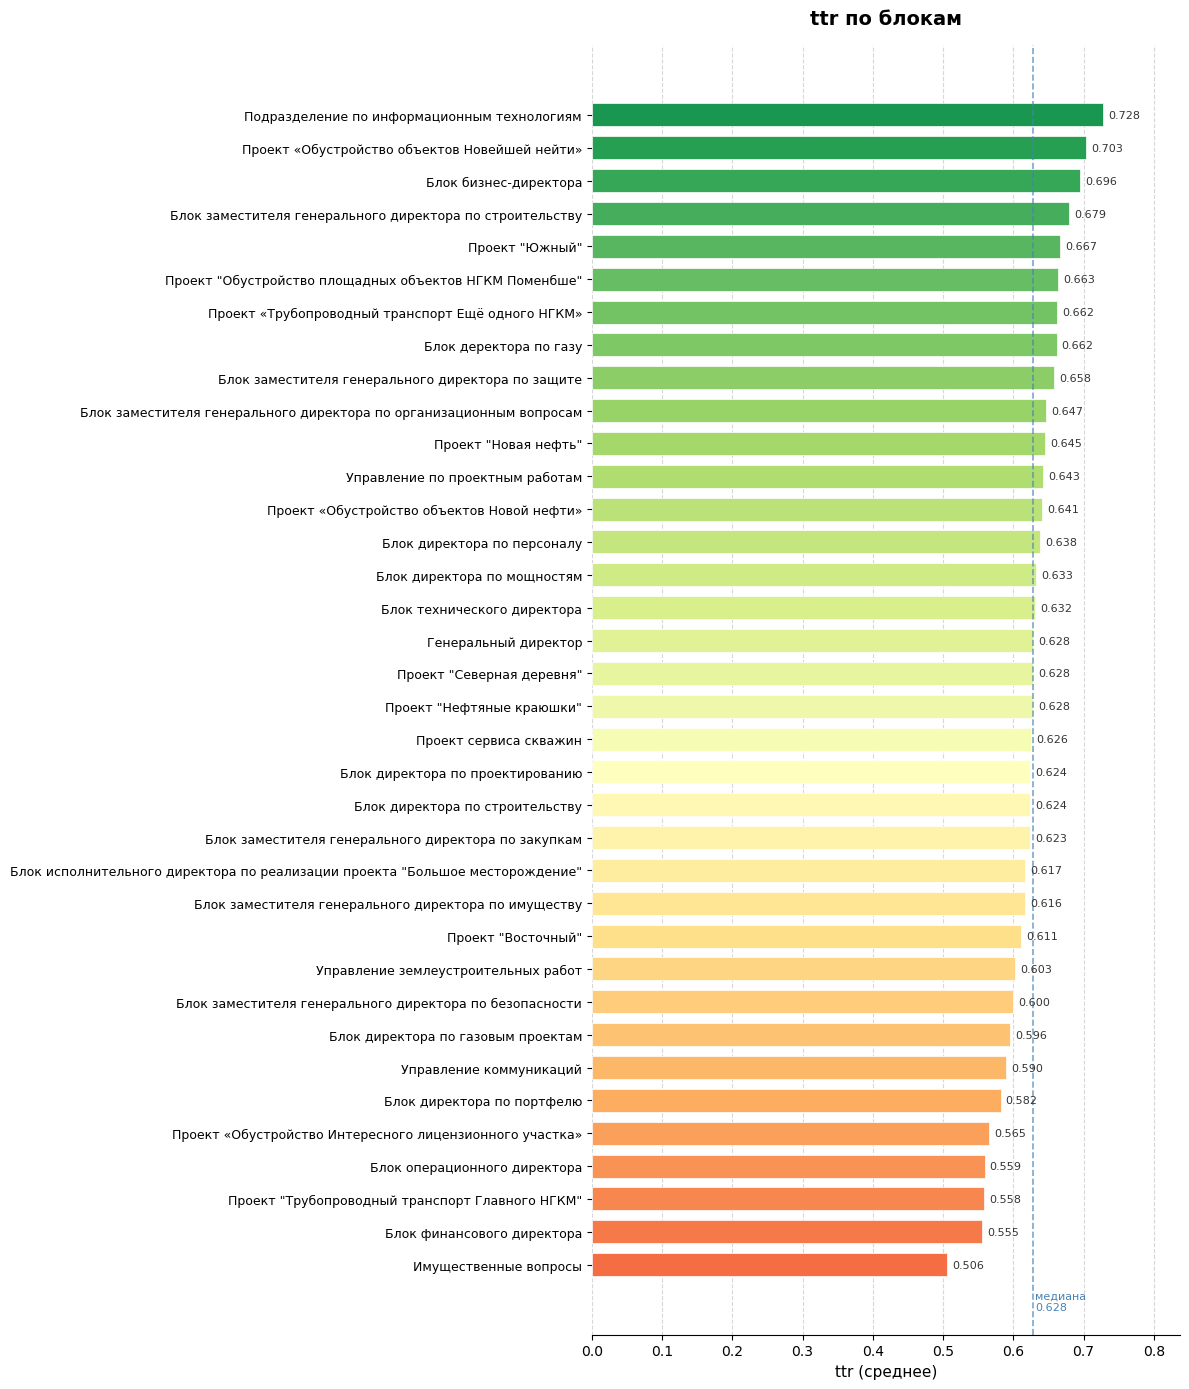

In [142]:
plot_metric_by_label(data, 'ttr')                 # лексическое разнообразие

Имущественные вопросы , самый низкий ttr. 

При этом письма имеют большой обьем слов.

 Низкий TTR при большом объёме может говорить о шаблонных юридических формулировках, которые повторяются.

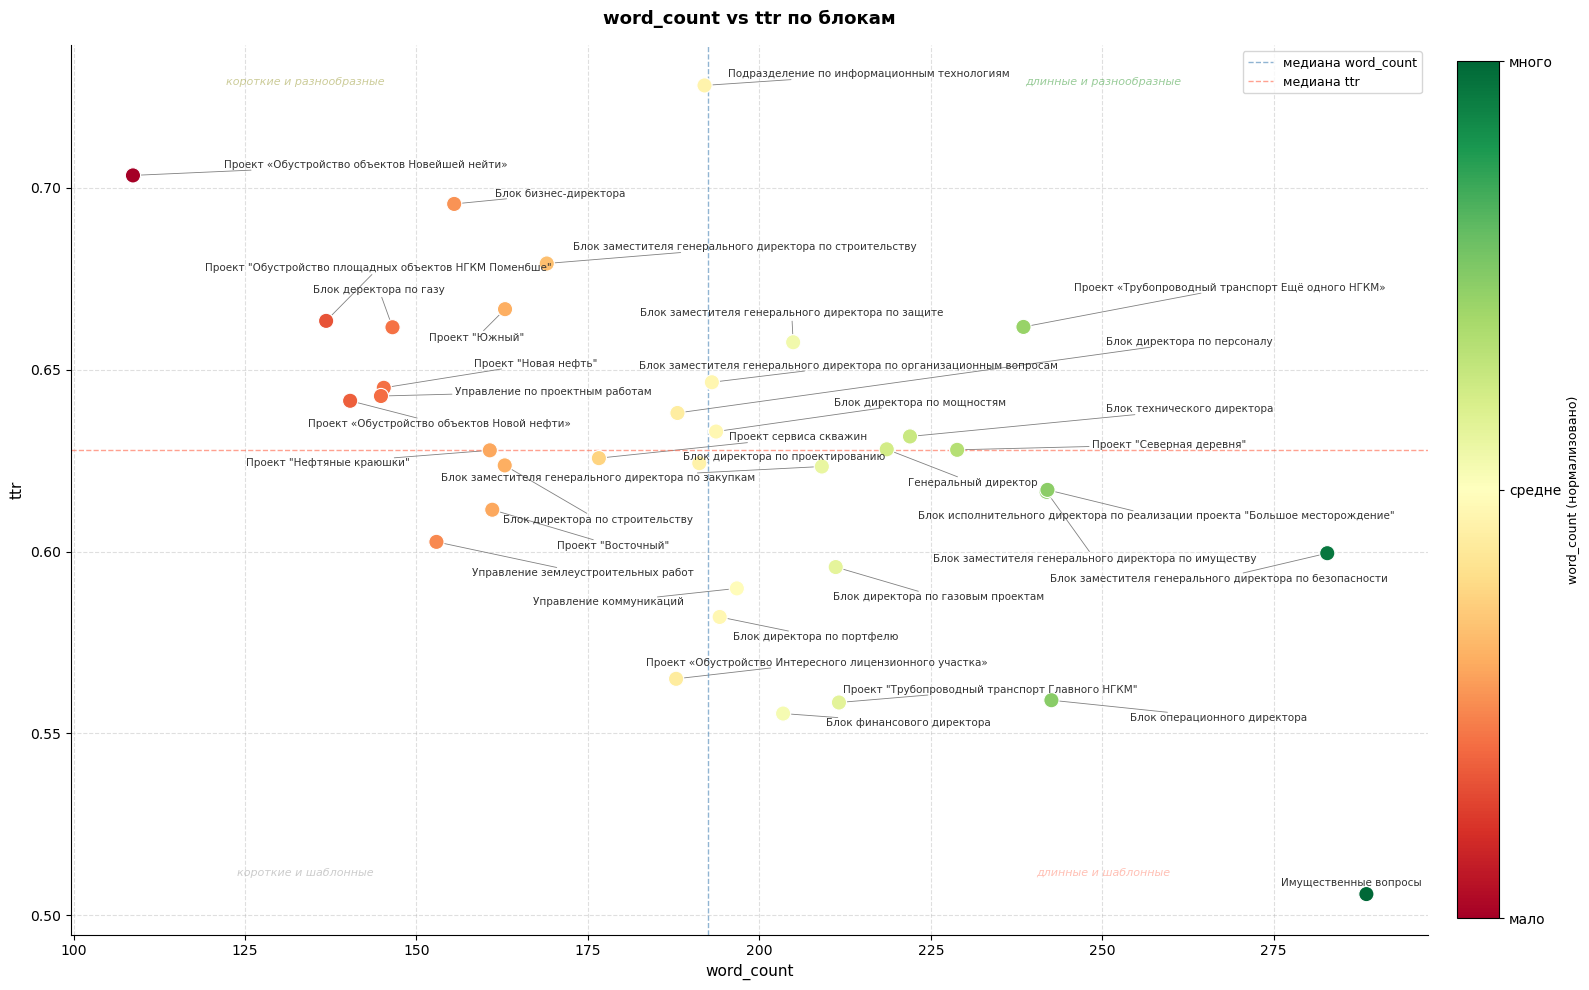

In [143]:
plot_scatter_two_metrics(data, 'word_count', 'ttr')

Блок Имущественные вопросы состоит из длинных шаблонных фраз и перечней и легко отделим от остальных блоков.

Блок подразделение по информационным технологиям самый разнообразный.

Письма по проектам в основной своей массе более короткие и разнообразные.  Письма с блоками более длинные и формализованные.
___
rttr

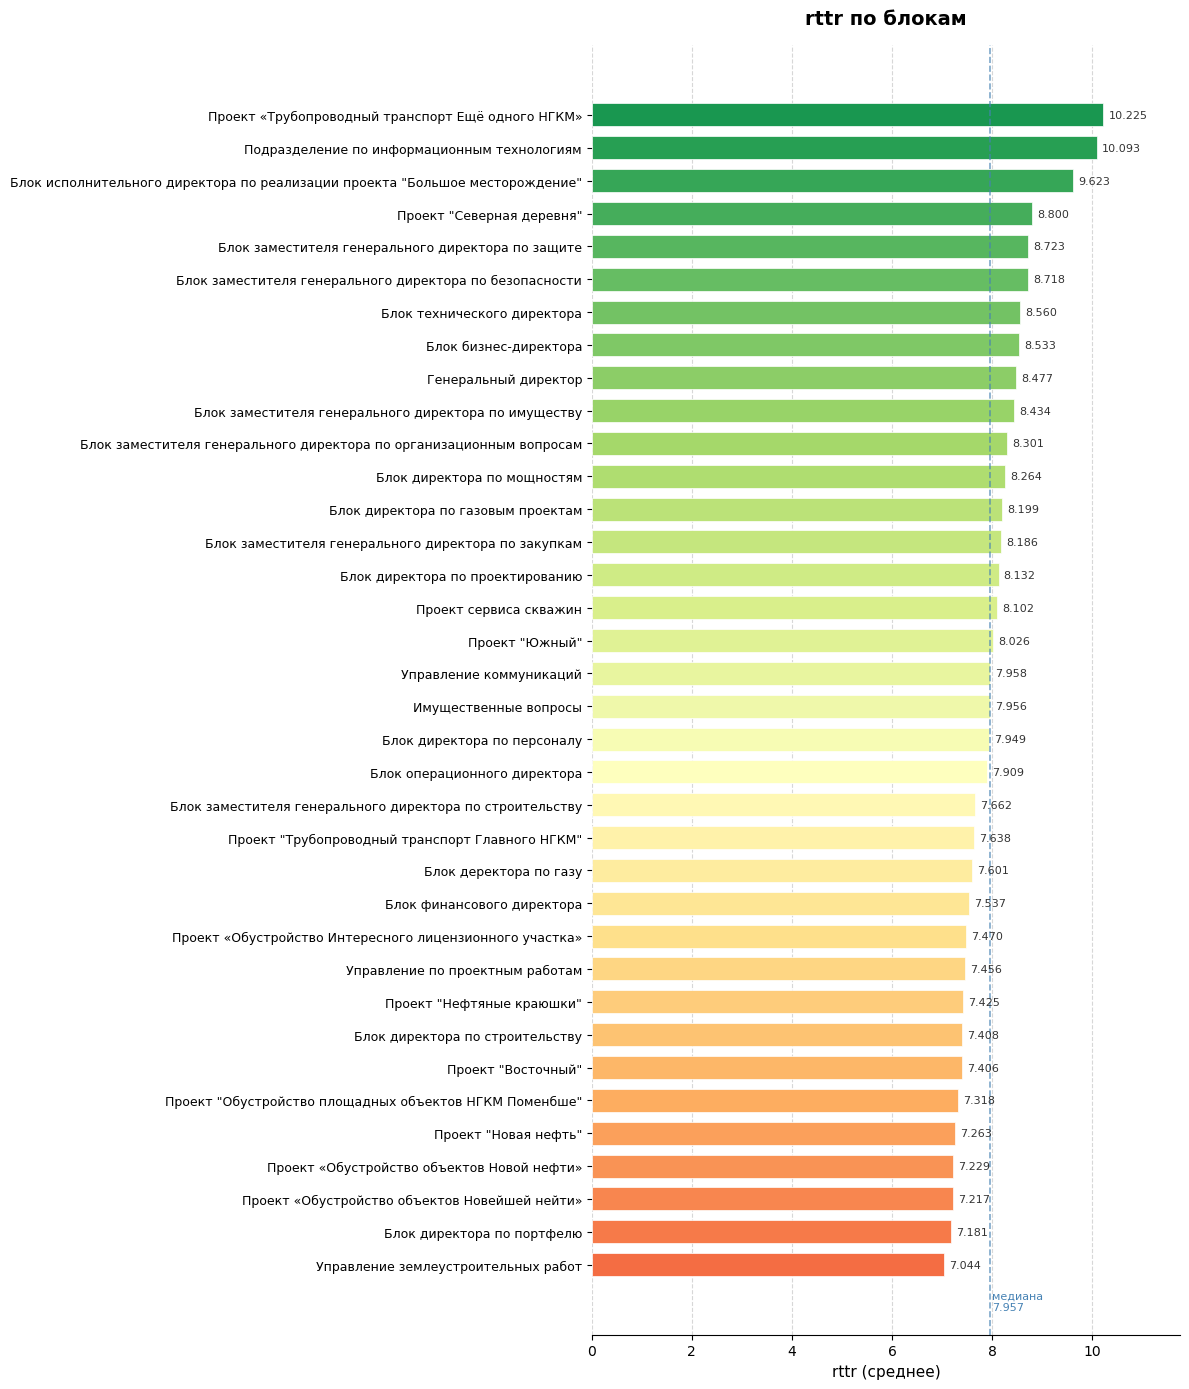

In [144]:
plot_metric_by_label(data, 'rttr')                 # лексическое разнообразие без учета длинны предложений


Здесь  так же можно заметить что Блоки с названиями начинающимися на  "Блок" в большинстве своем более лексически разнообразны в отличие от Блоков с названиями "Проект"

___
Средняя длина слов

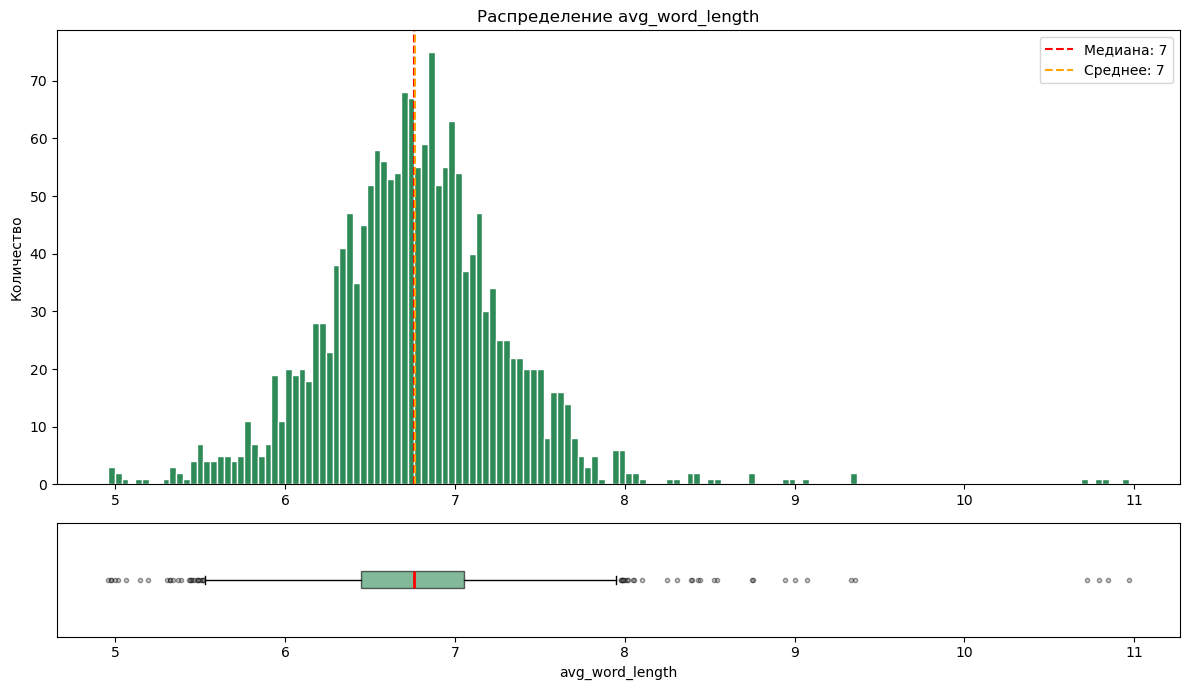

In [145]:
plot_length_distribution(data, 'avg_word_length')

Распределение похоже на нормальные, посмотрим  крайние значения что бы оценить их на аномальность.

In [146]:
data['avg_word_length'].describe()


count    1750.000000
mean        6.765870
std         0.557293
min         4.957082
25%         6.444444
50%         6.756584
75%         7.055254
max        10.968610
Name: avg_word_length, dtype: float64

In [147]:
print(data[data['avg_word_length'] < 5]['text'].iloc[0])

[ORGANIZATION] юридический адрес: [LOCATION] фактический адрес: [LOCATION] почтовый адрес: [LOCATION] ОГРН [ID] ИНН/КПП [ID] [DATE_TIME] No [DOCUMENT_NUMBER] на исх. No от [DATE_TIME] [PERSON] [CONTACT] Начальнику управления по ПИР и взаимодействию с надзорными органами [ORGANIZATION] [PERSON] [CONTACT] О направлении гидравлического расчета и схемы водовода (ш. ЧНФ1-ВЗ0) Уважаемый [PERSON]! В рамках выполнения договора по объекту Расширение водозаборных сооружений Чаяндинского НГКМ (ЧНФ1-ВЗ) направляем на рассмотрение и согласование результаты гидравлического расчета низконапорных водоводов с расчетной схемой. Приложение: Гидравлический расчет и расчетная схема. Главный инженер по проектированию [PERSON] Исп.: [PERSON] [CONTACT] Расчетная схема низкого напорных водоводов Точка бреэку 70159x6 L8000* м Площадка насосной Результаты гидравлического расчета низкого напорных водоводов Данные по участкам Данные по трубам Название Начало Конец Расход жидкости м3/сут Длина, М Количество, шт. Вс

In [148]:
print(data[data['avg_word_length'] < 10]['text'].iloc[0])

[PERSON] Уважаемый [PERSON]! [ORGANIZATION] высоко ценит сложившиеся отношения между нашими предприятиями и заинтересовано в предоставлении геофизических услуг на объектах [ORGANIZATION]. Согласно письму [ORGANIZATION] от [DATE_TIME] No [DOCUMENT_NUMBER] о формировании бизнес-плана и СИП на 2025–2027 гг. просим Вас учесть индексацию расценок на услуги внутреннего сервиса на 2025 год в размере [FINANCIAL_DATA] при формировании бизнес-плана и заключении новых договоров на 2025 год и последующие годы, а также предлагаем Вам заключить дополнительные соглашения с индексацией расценок на 2025 год к следующим действующим договорам: * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]. Надеемся на понимание, долгосрочное и взаимовыгодное сотрудничество. С уважением, [PERSON] [CONTACT]


Письма по краям распределения не являются аномальными по своему наполнению.
___

Средняя длина предложений.

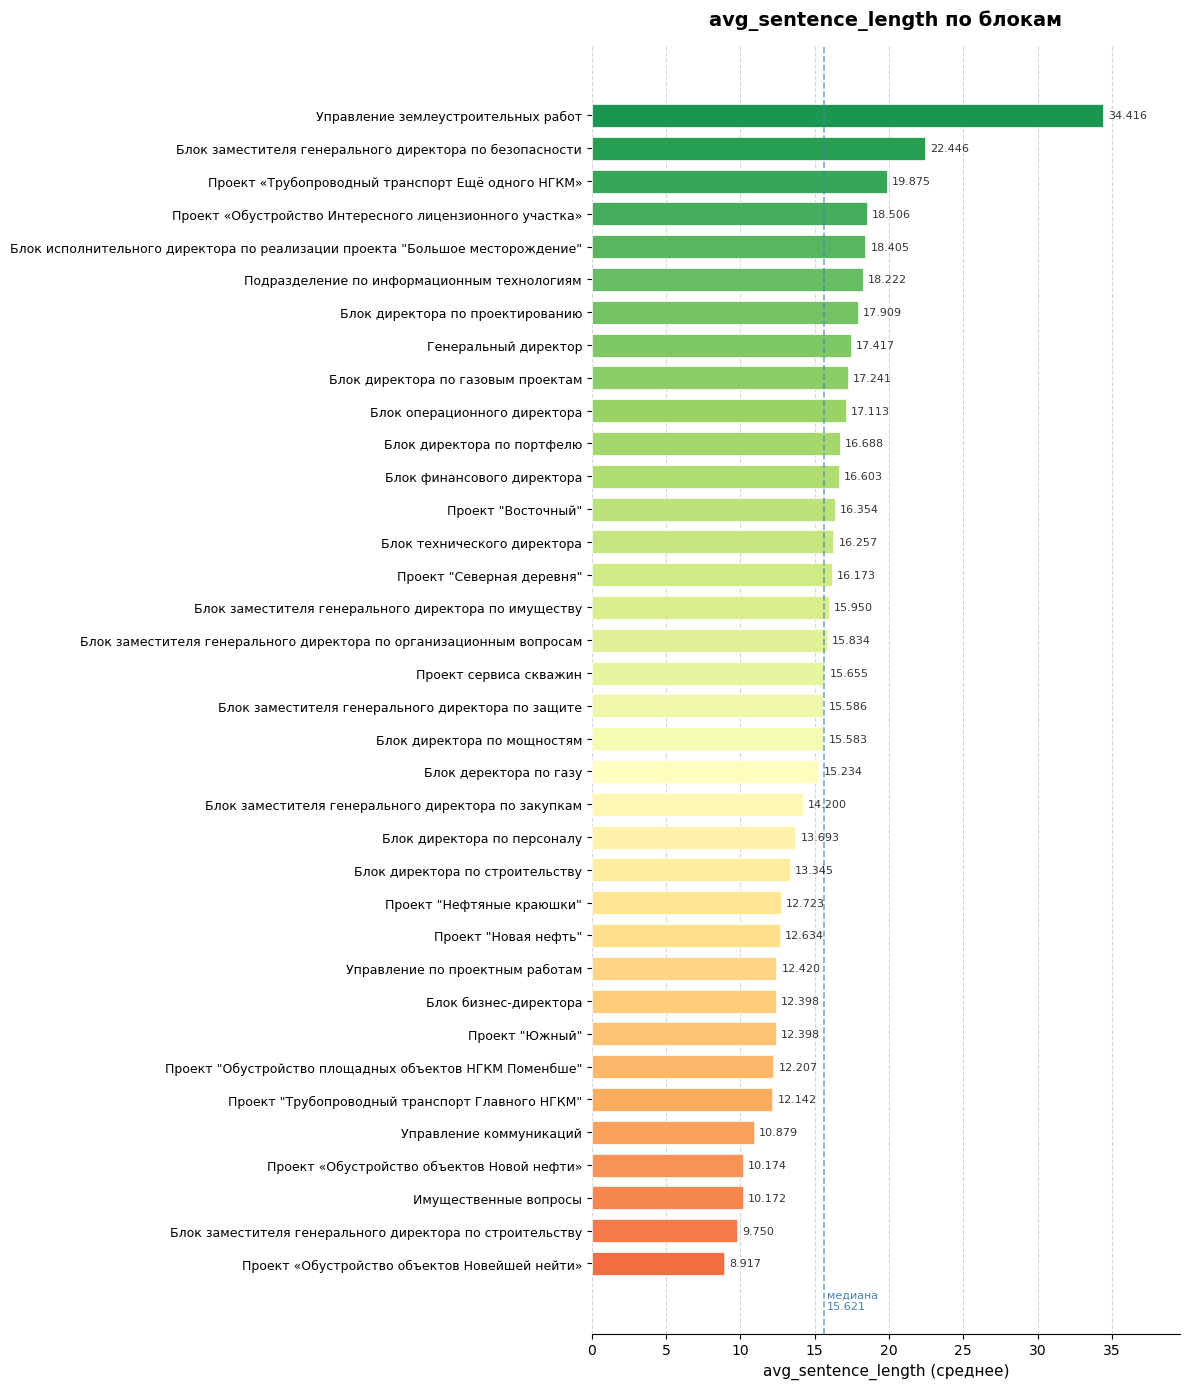

In [149]:
plot_metric_by_label(data, 'avg_sentence_length')

Ниже медианы расположены в основном операционные блоки, где требуется скорость и точность указаний и меньше терминогогии и бюрократизма.

Так же видим аномольно длинные предложения в блоке управление землеустроительных работ. 
По количеству уникальных слов этот блок так же впереди всех остальных.

Выделим письмо с самыми длинными предложениями в этом блоке и проверим его на аномалию.

In [150]:
data[data['label'] == 'Управление землеустроительных работ'].sort_values('avg_sentence_length', ascending=False).head(1)['text'].values[0]

'[ORGANIZATION] Саха Ореспууьылукэтин Экологияа, айылбаны тунасыга уонна ойыр ханаайыстыбатыгар министиэристибэтэ [ORGANIZATION] ГОСУДАРСТВЕННОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ РЕСПУБЛИКИ САХА (ЯКУТИЯ) [OBJECT] 678170, [LOCATION] Тел: [CONTACT]; [CONTACT] e-mail: [CONTACT] [DATE_TIME] No[DOCUMENT_NUMBER] [ORGANIZATION] Федорову [PERSON] Между [ORGANIZATION] и [ORGANIZATION] заключены договора аренды лесных участков: * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCIAL_DATA] га под дорогу автомобильную; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCИAL_DATA] га под дорогу автомобильную; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCIAL_DATA] га под Площадку производственную с покрытием, дорога автомобильная, линия электропередачи воздушная, кабельная всех классов напряжения, трубопровод подземный; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCIAL_DATA] га под Площадку производственную с покрытием; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [

Видим, что данное письмо содержит огромный перечень, который распарсился как одно предложение, в этом и есть причина аномально длинных предложений в данном блоке.

___
Доля длинных слов в тексте

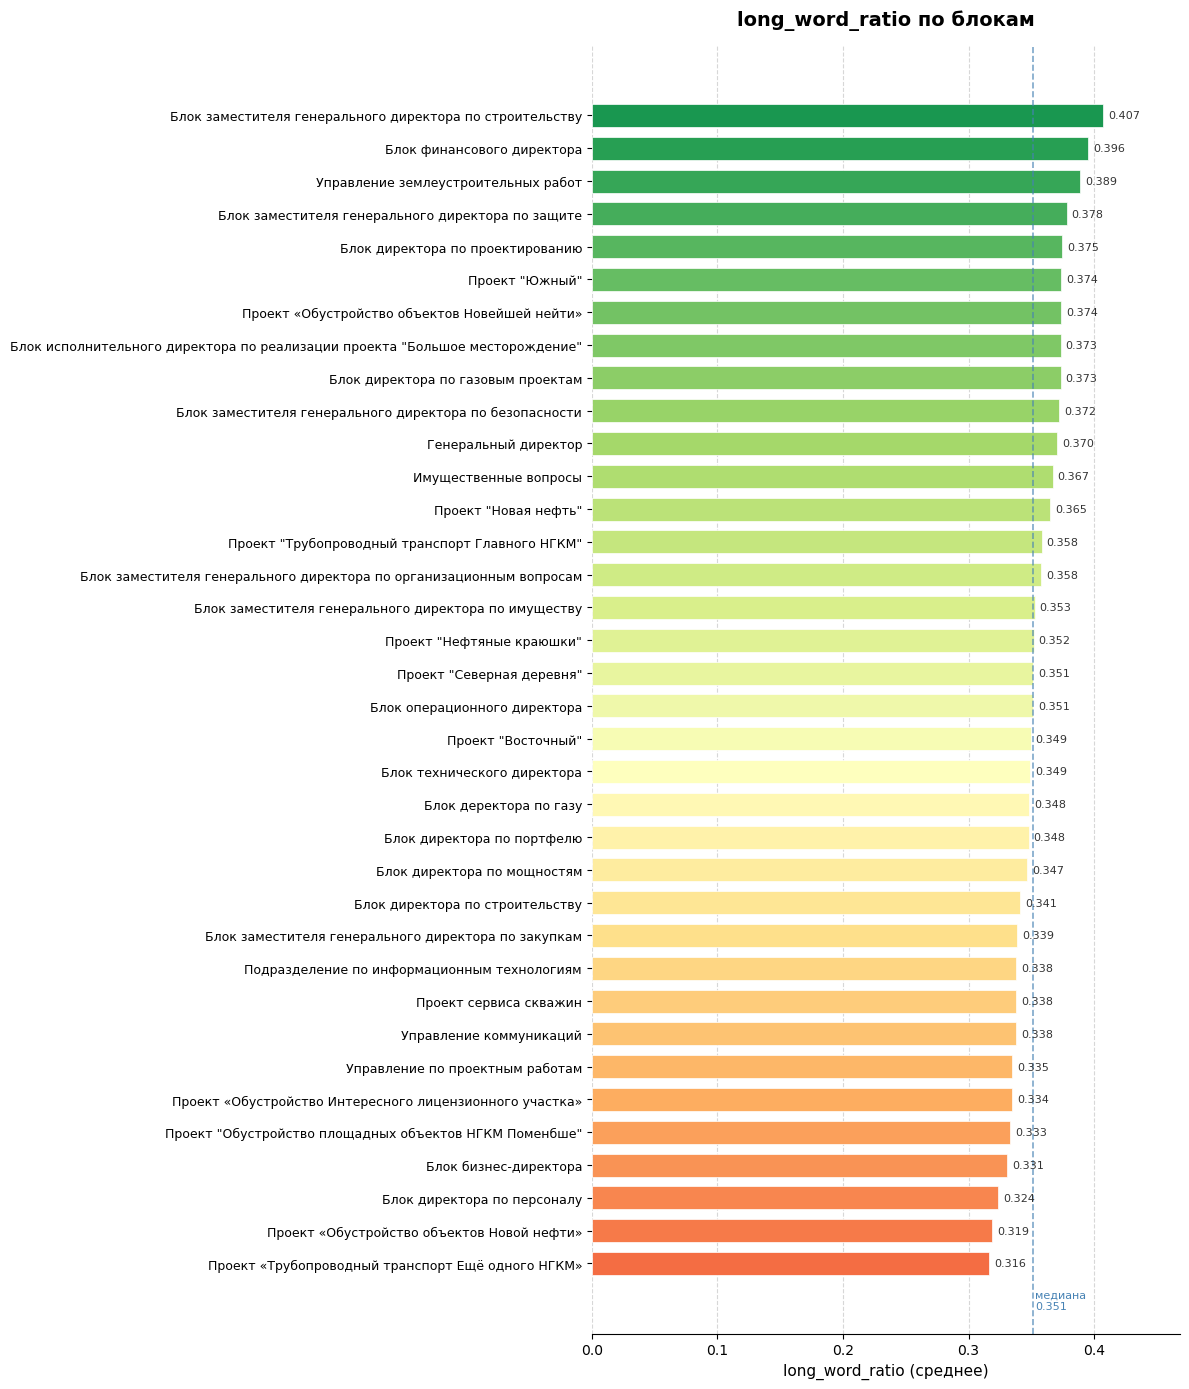

In [151]:
plot_metric_by_label(data, 'long_word_ratio')

По данному признаку разброс очень слабый, по этому он  был бы мало чем полезен при классификации
___

Hapax - доля уникальных слов.

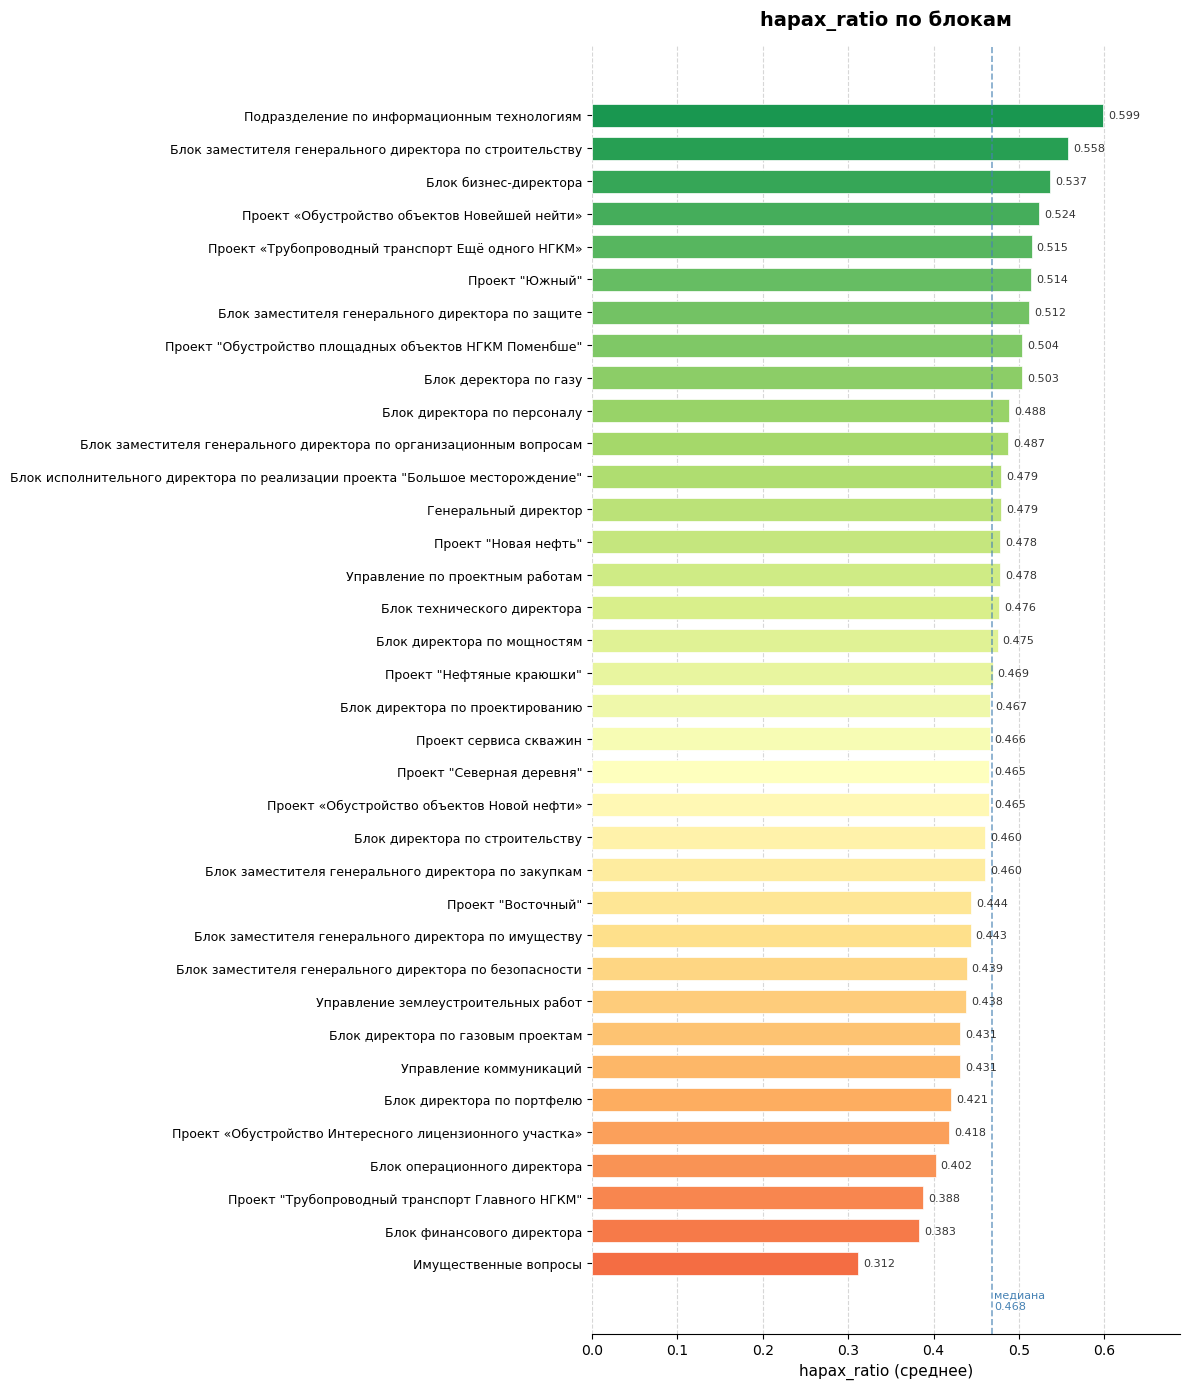

In [152]:
plot_metric_by_label(data, 'hapax_ratio')  

Проект «Трубопроводный транспорт Ещё одного НГКМ» — на long_word_ratio был последним (0.316), а на hapax_ratio высоко (0.515).

Короткие слова, но каждое уникально что может указывать на разнообразие тем в переписке по проекту.

Подразделение по информационным технологиям лидирует с большим отрывом, но из за того что в качестве примеров имеет всего два коротких письма, сложно обобощить о нем информацию по данному паттерну.

Блоки внизу графика — шаблонная документация, блоки вверху — живая уникальная переписка.
___

Оценим блоки в совокупности.

In [49]:
data.groupby('label')[['ttr', 'rttr', 'avg_sentence_length', 'word_count',
                     'long_word_ratio', 'hapax_ratio']].mean().sort_values('rttr', ascending=False)

,ttr,rttr,avg_sentence_length,word_count,long_word_ratio,hapax_ratio
label,,,,,,
Проект «Трубопроводный транспорт Ещё одного НГКМ»,0.661755,10.225052,19.875000,238.500000,0.316168,0.514788
Подразделение по информационным технологиям,0.728158,10.093220,18.222222,192.000000,0.337830,0.598683
"Блок исполнительного директора по реализации проекта ""Большое месторождение""",0.615299,9.544733,18.009337,239.600000,0.371723,0.476793
"Проект ""Северная деревня""",0.627960,8.800412,16.173329,228.833333,0.351183,0.465456
Блок заместителя генерального директора по защите,0.657543,8.723177,15.586173,204.923077,0.378132,0.512066
Блок заместителя генерального директора по безопасности,0.599535,8.717909,22.446383,282.796748,0.371846,0.438660
Блок технического директора,0.631638,8.560306,16.257029,221.955285,0.349321,0.476379
Блок бизнес-директора,0.695572,8.532973,12.398399,155.500000,0.330975,0.536867
Генеральный директор,0.628101,8.476754,17.416642,218.568627,0.370439,0.478562


**Выводы:**

Имеется группа блоков содержащих длинные шаблонные документы (низкий ttr и низкий hapax_ratio):

Имущественные вопросы (ttr=0.51, hapax=0.31)
Блок операционного директора (ttr=0.56, hapax=0.40)
Проект «Трубопроводный транспорт Главного НГКМ» (ttr=0.56, hapax=0.39)
Блок финансового директора (ttr=0.56, hapax=0.38)
Управление коммуникаций (ttr=0.59, hapax=0.43)

Есть напротив группа с высоким ttr и высоким hapax_ratio — уникальная адресная переписка:

Подразделение по информационным технологиям (ttr=0.73, hapax=0.60)
Блок бизнес-директора (ttr=0.70, hapax=0.54)
Проект «Обустройство объектов Новейшей нейти» (ttr=0.70, hapax=0.52)
Блок заместителя ГД по строительству (ttr=0.68, hapax=0.56)

Но они содержат мало примеров.
Отдельно выделяется аномалия по длине предложений:

Управление землеустроительных работ — avg_sentence_length=34.4 при среднем word_count=153, что вдвое выше любого другого блока и указывает на специфический стиль документов (перечисления без точек, длинные юридические конструкции).
Блок заместителя ГД по безопасности — avg_sentence_length=22.4 при максимальном word_count=283.

Большинство блоков, а именно около 25, по рассмотренным характеристикам практически не отличимы и находятся в средних значениях:

- word_count: 140–245
- ttr: 0.59–0.67
- hapax_ratio: 0.44–0.52
- long_word_ratio: 0.33–0.38
- avg_sentence_length: 12–20

Попробуем найти отличия семантическими методами.


___

### Класстеризация по смысловому наполнению.
Подготовим данные извлечем тексты из датафрема и преобразуем их в эмбеддинги.

Для эмбеддингов выбрана модель paraphrase-multilingual-MiniLM-L12-v2. Она относится к семейству Sentense-Bert. Легкая и работает с русским языком.

In [50]:
texts = data["text"].astype(str).tolist()
device = "cpu"
#  Эмбеддинги 
print("Encoding...")
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
embeddings = model.encode(texts, batch_size=64, show_progress_bar=True)

Encoding...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Снижаем размерность векторных представлений до 2D плоскости

In [51]:
print("UMAP...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=40,      
    min_dist=0.1, # для плотности и компактности кластеров
    metric="cosine",
    random_state=42
)
embedding_2d = reducer.fit_transform(embeddings)

UMAP...


Кластеризуем тексты в 2D пространстве с помощью HDBSCAN

In [52]:
print("Clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,   # 1% от датасета 
    min_samples=5,
    metric="euclidean"     # кластеризуем в 2D пространстве
)
cluster_labels = clusterer.fit_predict(embedding_2d)

Clustering...


Визуализируем.

In [53]:
labels = data["label"].astype(str).tolist()
# данные для визуализации
df_plot = pd.DataFrame({
    "x":           embedding_2d[:, 0],
    "y":           embedding_2d[:, 1],
    "label":       labels,
    "cluster":     cluster_labels.astype(str),
    "text_preview": [t[:120] + "..." for t in texts]
})

fig = px.scatter(
    df_plot,
    x="x", y="y",
    color="label",
    hover_data=["text_preview", "cluster", "label"],
    title="UMAP — семантическое пространство писем (цвет = разметка)",
    color_discrete_sequence=px.colors.qualitative.Alphabet,  # 26 цветов
    width=1200, height=800,
    opacity=0.8
)
fig.update_traces(marker=dict(size=7))
fig.update_layout(legend=dict(
    font=dict(size=9),
    itemsizing="constant",
    title="Класс"
))
fig.write_html("umap_emails.html")
fig.show()
print("Готово → umap_emails.html")

# ── 7. Метрики совпадения кластеров с разметкой ───────────────────────────────
print( f"Найдено кластеров   : {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Шумовых точек       : {(cluster_labels == -1).sum()} / {len(cluster_labels)}")

Готово → umap_emails.html
Найдено кластеров   : 7
Шумовых точек       : 11 / 1755


In [54]:
# Посмотрим как разметка распределилась по кластерам
print("\nРаспределение классов по кластерам:")
crosstab = pd.crosstab(df_plot['label'], df_plot['cluster'])
crosstab


Распределение классов по кластерам:


cluster,-1,0,1,2,3,4,5,6
label,,,,,,,,
Блок бизнес-директора,0,0,0,0,8,0,0,0
Блок деректора по газу,2,0,0,0,68,0,0,1
Блок директора по газовым проектам,0,1,0,4,26,0,0,0
Блок директора по мощностям,1,0,0,14,210,0,0,16
Блок директора по персоналу,0,0,0,9,9,0,0,0
Блок директора по портфелю,0,0,0,1,23,0,0,0
Блок директора по проектированию,0,0,0,4,39,0,0,0
Блок директора по строительству,2,23,7,7,91,2,15,18
Блок заместителя генерального директора по безопасности,0,0,0,12,110,1,0,0


Найдем по кластерам часто встречающиеся фразы с помощью TF-IDF.

In [55]:
# Добавляем cluster_labels в основной датафрейм
data_clustered = data.iloc[:len(cluster_labels)].copy()
data_clustered['cluster'] = cluster_labels


#  Исключаем шум
data_no_noise = data_clustered[data_clustered['cluster'] != -1]

# TF-IDF по кластерам
group_texts = data_no_noise.groupby('cluster')['text'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)
tfidf_matrix = vectorizer.fit_transform(group_texts)
feature_names = vectorizer.get_feature_names_out()

# Топ-слова + какие классы разметки преобладают в кластере
print("=" * 150)
for i, cluster_id in enumerate(group_texts.index):
    # Топ слова
    row = tfidf_matrix[i].toarray()[0]
    top_idx = row.argsort()[::-1][:8]
    top_words = [feature_names[j] for j in top_idx if row[j] > 0]
    
    # Преобладающие классы разметки
    cluster_data = data_no_noise[data_no_noise['cluster'] == cluster_id]
    top_labels = cluster_data['label'].value_counts().head(3)
    n_total = len(cluster_data)
    
    print(f"\n {'=' * 40} Кластер {cluster_id} ({n_total} писем){'=' * 40}")
    print(f"   Топ слова : {' | '.join(top_words)}")
    print(f"   Топ классы:")
    for lbl, cnt in top_labels.items():
        pct = cnt / n_total * 100
        print(f"     {cnt:3d} ({pct:4.1f}%)  {lbl}")
print("=" * 150)


 ======================================== Кластер 0 (37 писем)========================================
   Топ слова : group до | position group | description financial_data | 1000в | product product | до выше | выше 1000в | гр
   Топ классы:
      23 (62.2%)  Блок директора по строительству
       7 (18.9%)  Блок технического директора
       4 (10.8%)  Проект «Обустройство Интересного лицензионного участка»

 ======================================== Кластер 1 (27 писем)========================================
   Топ слова : местонахождения | обособленного | обособленного подразделения | description | да | no2 location | стр | по document_number
   Топ классы:
      10 (37.0%)  Проект "Трубопроводный транспорт Главного НГКМ"
       7 (25.9%)  Проект «Обустройство объектов Новой нефти»
       7 (25.9%)  Блок директора по строительству

 ======================================== Кластер 2 (105 писем)========================================
   Топ слова : опасного | производственного объе

У нас выделилось 7 кластеров, большая часть писем сливается в кластере 3.

Разобьем кластеры на темы изходя из ключевых выделенных слов.

- Кластер 0:  Письма с финансовыми показателями, структурой должностей, данными по продуктам
- Кластер 1:  Данные о местоположении, адресах
- Кластер 2:  Производственная безопасность
- Кластер 3:  Размытый класс с общей тематикой.
- Кластер 4:  Данные, номера (возможно документов)
- Кластер 5:  Реквизиты писем
- Кластер 6:  Финансовые данные по филлиалам

___
### Тематическое моделирование LDA 
Для сравнения попробуем метод тематического моделирования -  Latent Dirichlet Allocation (LDA).

Текст разбивается на массив слов, удаляются стоп-слова, остальные слова приводятся к начальной форме(лемматизируются)

In [21]:
# удаляем плейсхолдеры
placeholder_pattern = re.compile(r'\[.*?\]')

# русские стоп-слова
STOP_WORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то',
    'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за',
    'бы', 'по', 'только', 'её', 'мне', 'было', 'вот', 'от', 'меня', 'ещё',
    'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли',
    'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь',
    'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей',
    'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя',
    'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз',
    'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того',
    'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один',
    'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем',
    'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой',
    'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про',
    'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впрочем',
    'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том',
    'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 'между',
    'это', 'мой', 'свой', 'наш', 'ваш', 'который', 'также', 'очень',
}

# загрузка модели spacy для русского
try:
    nlp = spacy.load("ru_core_news_sm")
except OSError:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "ru_core_news_sm"], check=True)
    nlp = spacy.load("ru_core_news_sm")

processed_texts = []

for text in data['text'].astype(str).tolist():
    doc = nlp(text)
    
    # лемматизация + удаление стоп-слов и пунктуации
    lemmas = [
        token.lemma_.lower() 
        for token in doc 
        if token.lemma_.lower() not in STOP_WORDS
        and not token.is_punct 
        and token.is_alpha
        and len(token.text) > 1
        and not placeholder_pattern.match(token.text)
    ]
    
    processed_texts.append(lemmas)

Получим векторное представление с помощью техники унитарного кодирования, называемой "Мешок слов"(BOW). Он превращает фразы или целые предложения в бинарные векторы.

In [155]:
# создаём словарь
dic = corpora.Dictionary(processed_texts)
dic.filter_extremes(no_below=5, no_above=0.5)  # убираем очень редкие и очень частые

# создаём корпус в формате BOW
bow_corpus = [dic.doc2bow(text) for text in processed_texts]

Запустим модель LDA

In [157]:
# задаём количество тем 
num_topics = 30
#Обучаем модель
lda_model = LdaMulticore(
    bow_corpus,
    num_topics=num_topics,
    id2word=dic,
    passes=10,
    workers=2,
    batch=True
)

/Users/kvt/miniconda3/envs/vkr_clean/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/Users/kvt/miniconda3/envs/vkr_clean/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Визуализируем

In [158]:
pyLDAvis.enable_notebook()

vis = gensim_lda.prepare(lda_model, bow_corpus, dic)
pyLDAvis.save_html(vis, 'lda_vis.html')
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
25     0.070452  0.084319       1        1  6.089287
2      0.050952  0.149510       2        1  5.381763
7      0.028359 -0.082266       3        1  5.191959
9     -0.084102  0.019756       4        1  5.021805
29     0.127169 -0.073194       5        1  4.943092
26     0.069871 -0.090237       6        1  4.767439
3      0.158811 -0.044923       7        1  4.661411
17     0.131010 -0.075119       8        1  4.566987
27    -0.060586  0.100227       9        1  3.944339
11    -0.040469 -0.157245      10        1  3.899761
15    -0.258553 -0.041862      11        1  3.884503
16     0.068851  0.095903      12        1  3.774491
19     0.107731 -0.064099      13        1  3.396246
20    -0.007851 -0.047913      14        1  3.183587
1     -0.066663 -0.104388      15        1  3.113426
12    -0.061526  0.063161      16        1  3.112723
6     -0.118429 -0.028874      17        1  2.893498
5      0.005420 -0.107395      18        1  2.836499
21     0.093242 -0.071204      19        1  2.728138
0     -0.112192  0.038728      20        1  2.585650
10     0.101016  0.007769      21        1  2.569102
4      0.023033  0.147200      22        1  2.422013
28    -0.026336  0.038050      23        1  2.317439
22     0.035730 -0.019603      24        1  2.192518
14     0.069033  0.082453      25        1  2.107196
13    -0.256581 -0.037618      26        1  2.079703
8     -0.002800  0.022097      27        1  2.012475
24     0.038281  0.087414      28        1  1.655349
23    -0.036257  0.087526      29        1  1.451835
18    -0.046616  0.021826      30        1  1.215763, topic_info=             Term         Freq        Total Category  logprob  loglift
37         number  1409.000000  1409.000000  Default  30.0000  30.0000
7         договор  1789.000000  1789.000000  Default  29.0000  29.0000
92         работа  2129.000000  2129.000000  Default  28.0000  28.0000
119  безопасность   526.000000   526.000000  Default  27.0000  27.0000
246        добыча   289.000000   289.000000  Default  26.0000  26.0000
..            ...          ...          ...      ...      ...      ...
237          факс    11.333056   670.766758  Topic30  -5.1953   0.3291
107   технический    11.444808   810.695988  Topic30  -5.1855   0.1494
92         работа    12.142293  2129.898135  Topic30  -5.1264  -0.7573
234           тел    10.555021   620.557880  Topic30  -5.2665   0.3358
218        region    10.451786   281.086217  Topic30  -5.2763   1.1179

[1956 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1338     18  0.293173     action
1338     24  0.586347     action
167       1  0.009707    country
167       2  0.087361    country
167       4  0.009707    country
...     ...       ...        ...
2922     18  0.046877       янао
2922     30  0.796904       янао
2302      3  0.784448  ёмкостный
2302      5  0.071313  ёмкостный
2302     25  0.071313  ёмкостный

[11250 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[26, 3, 8, 10, 30, 27, 4, 18, 28, 12, 16, 17, 20, 21, 2, 13, 7, 6, 22, 1, 11, 5, 29, 23, 15, 14, 9, 25, 24, 19])

In [ ]:
from collections import Counter

processed_by_class = {}

for text, label in zip(data['text'].astype(str).tolist(), data['label'].tolist()):
    doc = nlp(text)
    
    
    if label not in processed_by_class:
        processed_by_class[label] = []
    processed_by_class[label].extend(lemmas)
i = 0
# Топ-10 слов для каждого класса
for label in sorted(processed_by_class):
    i += 1
    top = Counter(processed_by_class[label]).most_common(10)
    print(f"{i} «{label}»: {', '.join(f'{w}({c})' for w, c in top)}")

1 «Блок бизнес-директора»: дата(32), газоанализатор(32), адрес(24), область(24), серия(24), компания(16), совещание(16), главный(16), метролог(16), цсм(16)
2 «Блок деректора по газу»: дата(284), газоанализатор(284), адрес(213), область(213), серия(213), компания(142), совещание(142), главный(142), метролог(142), цсм(142)
3 «Блок директора по газовым проектам»: дата(124), газоанализатор(124), адрес(93), область(93), серия(93), компания(62), совещание(62), главный(62), метролог(62), цсм(62)
4 «Блок директора по мощностям»: дата(964), газоанализатор(964), адрес(723), область(723), серия(723), компания(482), совещание(482), главный(482), метролог(482), цсм(482)
5 «Блок директора по персоналу»: дата(72), газоанализатор(72), адрес(54), область(54), серия(54), компания(36), совещание(36), главный(36), метролог(36), цсм(36)
6 «Блок директора по портфелю»: дата(96), газоанализатор(96), адрес(72), область(72), серия(72), компания(48), совещание(48), главный(48), метролог(48), цсм(48)
7 «Блок дир

При удалении плейсхолдеров [ORGANIZATION], [PERSON] и т д, данные разбились разнообразнее,  хотя все еще большая часть близка к друг другу. Попробуем удалить их в данных для кластеризации. 

___
Удалим все плейсхолдеры 

In [ ]:
def replace_placeholders(text: str) -> str:
    replacements = {
        r'\[ORGANIZATION\]': 'компания',
        r'\[PERSON\]': 'сотрудник',
        r'\[LOCATION\]': 'место',
        r'\[DATE_TIME\]': '',
        r'\[FINANCIAL_DATA\]': '',
        r'\[.*?\]': '',  # всё остальное удаляем
    }
    
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text)
    
    return re.sub(r'\s+', ' ', text).strip()

df = data.copy()
df['text'] = df['text'].apply(replace_placeholders)

In [ ]:
texts = df["text"].astype(str).tolist()
device = "cpu"
#  Эмбеддинги 
print("Encoding...")
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
embeddings = model.encode(texts, batch_size=64, show_progress_bar=True)

Encoding...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

In [ ]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=40,      
    min_dist=0.1, # для плотности и компактности кластеров
    metric="cosine",
    random_state=42
)
embedding_2d = reducer.fit_transform(embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,   # 1% от датасета 
    min_samples=5,
    metric="euclidean"     # кластеризуем в 2D пространстве
)
cluster_labels = clusterer.fit_predict(embedding_2d)

labels = data["label"].astype(str).tolist()
# данные для визуализации
df_plot = pd.DataFrame({
    "x":           embedding_2d[:, 0],
    "y":           embedding_2d[:, 1],
    "label":       labels,
    "cluster":     cluster_labels.astype(str),
    "text_preview": [t[:120] + "..." for t in texts]
})

fig = px.scatter(
    df_plot,
    x="x", y="y",
    color="label",
    hover_data=["text_preview", "cluster", "label"],
    title="UMAP — семантическое пространство писем (цвет = разметка)",
    color_discrete_sequence=px.colors.qualitative.Alphabet,  # 26 цветов
    width=1200, height=800,
    opacity=0.8
)
fig.update_traces(marker=dict(size=7))
fig.update_layout(legend=dict(
    font=dict(size=9),
    itemsizing="constant",
    title="Класс"
))
fig.write_html("umap_emails_with_no_placeholders.html")
fig.show()
print("Готово → umap_emails_with_no_placeholders.html")

# ── 7. Метрики совпадения кластеров с разметкой ───────────────────────────────
print( f"Найдено кластеров   : {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Шумовых точек       : {(cluster_labels == -1).sum()} / {len(cluster_labels)}")

Готово → umap_emails_with_no_placeholders.html
Найдено кластеров   : 2
Шумовых точек       : 0 / 1755


Удаление плейсхолдеров только ухудшило качество кластеризации, данные практически слились.

После всех изменений сохраним данные в файле.

In [ ]:
new = data[['text', 'label']]

In [ ]:
!ls ../Data/

data.json


In [ ]:
new.to_csv("../Data/data_after_eda.csv", index=False)